This project aims to build a credit risk model for a Buy Now Pay Later (BNPL) platform to predict customer default. The objective is to help lenders identify high-risk customers, reduce losses, and make better credit decisions using data-driven insights.

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

You should consider upgrading via the 'c:\Users\BHAVYA PATEL\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")

credit_score: Indicates borrower creditworthiness
monthly_income: Measures repayment capacity
missed_payments: Captures past repayment behavior
repayment_delay_days: Indicates payment discipline
default_flag: Target variable (1 = default, 0 = non-default)

In [6]:
df.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


In [7]:
df = df.drop(['risk_score', 'customer_segment'], axis=1)

In [8]:
df['default_flag'] = df['default_flag'].astype(int)

In [9]:
df.isnull().sum()

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
dtype: int64

In [10]:
df['default_flag'].value_counts(normalize=True)

default_flag
0    0.609473
1    0.390527
Name: proportion, dtype: float64

Customers who default tend to have significantly lower credit scores compared to non-defaulters. This confirms that credit score is a strong predictor of default risk and should be an important feature in the model.

<Axes: xlabel='default_flag', ylabel='credit_score'>

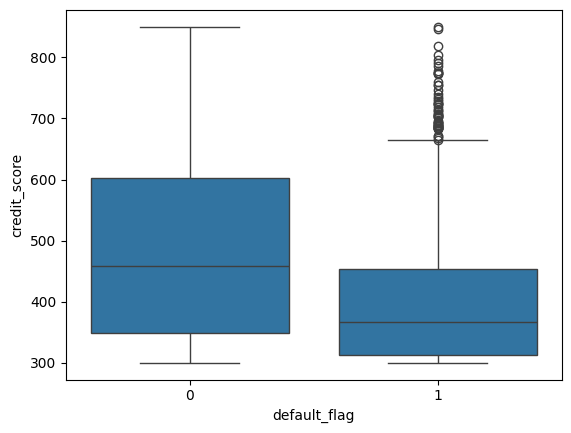

In [11]:
import seaborn as sns
sns.boxplot(x='default_flag', y='credit_score', data=df)

In [16]:
df.groupby('default_flag')['credit_score'].describe()

,count,mean,std,min,25%,50%,75%,max
default_flag,,,,,,,,
0,6305.0,483.606979,147.712088,300.0,349.0,458.0,603.0,850.0
1,4040.0,392.881188,93.049211,300.0,312.0,367.0,453.0,850.0


Defaulters have significantly lower credit scores compared to non-defaulters, with a median score of approximately 367 versus 458. This clear separation indicates that credit score is a strong predictor of default risk and should play a key role in the model. The overlap in maximum values suggests that while credit score is important, it is not sufficient alone to fully distinguish risky customers.

Defaulters show a higher number of missed payments, indicating that past repayment behavior is a critical indicator of future default risk.

<Axes: xlabel='default_flag', ylabel='missed_payments'>

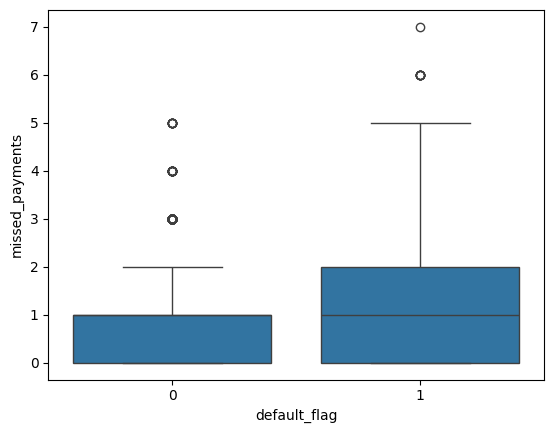

In [12]:
sns.boxplot(x='default_flag', y='missed_payments', data=df)

In [17]:
df.groupby('default_flag')['missed_payments'].describe()

,count,mean,std,min,25%,50%,75%,max
default_flag,,,,,,,,
0,6305.0,0.798731,0.822393,0.0,0.0,1.0,1.0,5.0
1,4040.0,1.354950,1.140208,0.0,0.0,1.0,2.0,7.0


While the median number of missed payments is similar across both groups, defaulters exhibit a higher average and upper distribution, with the 75th percentile reaching 2 compared to 1 for non-defaulters. This suggests that frequent missed payments are associated with increased default risk, even if occasional missed payments are common across all customers.

Customers with longer repayment delays are more likely to default, suggesting that delayed payments are an early warning signal of credit deterioration.

<Axes: xlabel='default_flag', ylabel='repayment_delay_days'>

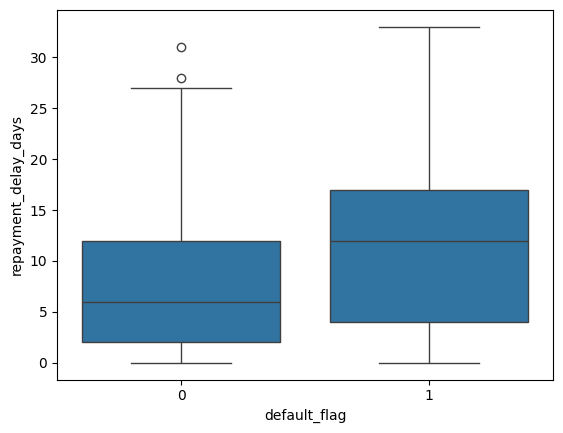

In [13]:
sns.boxplot(x='default_flag', y='repayment_delay_days', data=df)

In [18]:
df.groupby('default_flag')['repayment_delay_days'].describe()

,count,mean,std,min,25%,50%,75%,max
default_flag,,,,,,,,
0,6305.0,7.205393,5.961741,0.0,2.0,6.0,12.0,31.0
1,4040.0,11.142079,7.271117,0.0,4.0,12.0,17.0,33.0


Defaulters exhibit significantly longer repayment delays, with a median delay of 12 days compared to 6 days for non-defaulters. This indicates that repayment delay is a strong behavioral indicator of credit risk and can serve as an early warning signal of potential default.The wider spread among defaulters suggests greater instability in repayment behavior.

A new feature, loan_to_income, was created to measure the borrower’s financial burden. This is a commonly used metric in credit risk analysis to assess whether a loan amount is sustainable relative to income. 
Higher loan-to-income ratios are associated with increased default risk, indicating that customers with higher financial burden are more likely to fail in repayment.

<Axes: xlabel='default_flag', ylabel='loan_to_income'>

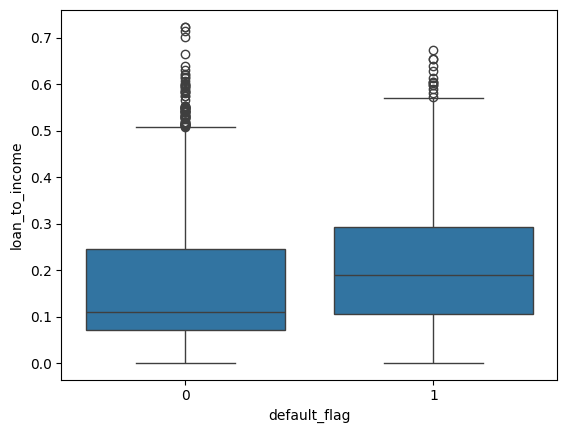

In [14]:
df['loan_to_income'] = df['purchase_amount'] / df['monthly_income']

sns.boxplot(x='default_flag', y='loan_to_income', data=df)

In [19]:
df.groupby('default_flag')['loan_to_income'].describe()

,count,mean,std,min,25%,50%,75%,max
default_flag,,,,,,,,
0,6305.0,0.163783,0.122366,0.000811,0.070959,0.109246,0.246034,0.723460
1,4040.0,0.208052,0.124011,0.001087,0.106020,0.189629,0.292285,0.674302


Defaulters have a higher loan-to-income ratio, with a median of approximately 0.19 compared to 0.11 for non-defaulters. This indicates that customers with higher financial burden relative to their income are more likely to default, making this a key risk metric. 

The analysis identifies several important drivers of default risk in the BNPL dataset. Customers who default tend to have significantly lower credit scores, indicating weaker creditworthiness. Behavioral variables emerge as strong predictors, with defaulters showing higher repayment delays and a greater number of missed payments, reflecting poor repayment discipline.

Additionally, financial burden plays a critical role, as defaulters exhibit higher loan-to-income ratios, suggesting that affordability constraints increase the likelihood of default.

Overall, the results indicate that while traditional factors like credit score remain important, behavioral indicators and loan burden provide stronger and more actionable signals of default risk, making them essential for effective credit risk modeling and decision-making.

In [15]:
df = df.drop(['user_id', 'transaction_date'], axis=1)

In [24]:
df = pd.get_dummies(df, drop_first=True)

In [25]:
X = df.drop('default_flag', axis=1)
y = df['default_flag']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\Users\BHAVYA PATEL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
X.dtypes

age                                int64
monthly_income                   float64
credit_score                       int64
purchase_amount                  float64
bnpl_installments                  int64
repayment_delay_days               int64
missed_payments                    int64
app_usage_frequency              float64
debt_to_income_ratio             float64
loan_to_income                   float64
employment_type_Self-Employed       bool
employment_type_Student             bool
employment_type_Unemployed          bool
product_category_Electronics        bool
product_category_Fashion            bool
product_category_Home               bool
product_category_Sports             bool
location_Canada                     bool
location_Germany                    bool
location_India                      bool
location_UK                         bool
location_USA                        bool
dtype: object

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[966 267]
 [424 412]]
              precision    recall  f1-score   support

           0       0.69      0.78      0.74      1233
           1       0.61      0.49      0.54       836

    accuracy                           0.67      2069
   macro avg       0.65      0.64      0.64      2069
weighted avg       0.66      0.67      0.66      2069



The model fails to identify a significant number of defaulters, with 424 false negatives. This is critical because misclassifying risky customers as safe can lead to financial losses in a real-world lending scenario.

Recall (default = 1) = 0.49

The model captures only 49% of actual defaulters, indicating that nearly half of risky customers are not being detected.

Precision (default = 1) = 0.61

When the model predicts a default, it is correct about 61% of the time, suggesting moderate reliability in identifying risky customers.

Accuracy = 67%

While overall accuracy is 67%, it does not fully reflect model performance, as correctly identifying defaulters is more important than overall correctness in credit risk applications.

In a BNPL lending context, failing to identify defaulters (false negatives) is more costly than incorrectly rejecting good customers. The current model shows moderate performance but requires improvement in detecting high-risk customers to minimize potential losses.

The Logistic Regression model achieves moderate performance with an accuracy of 67%. While it performs reasonably well in identifying non-defaulters, it struggles to detect defaulters, with a recall of 49%. This indicates that a significant number of risky customers are not being identified. From a credit risk perspective, this limitation is critical, as undetected defaulters can lead to financial losses. Improving recall for the default class should be prioritized through techniques such as class balancing and more advanced models.

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\Users\BHAVYA PATEL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[837 396]
 [310 526]]
              precision    recall  f1-score   support

           0       0.73      0.68      0.70      1233
           1       0.57      0.63      0.60       836

    accuracy                           0.66      2069
   macro avg       0.65      0.65      0.65      2069
weighted avg       0.67      0.66      0.66      2069



The Logistic Regression model achieves moderate performance with an accuracy of 67%. While it performs reasonably well in identifying non-defaulters, it struggles to detect defaulters, with a recall of 49%. This indicates that a significant number of risky customers are not being identified. From a credit risk perspective, this limitation is critical, as undetected defaulters can lead to financial losses. Improving recall for the default class should be prioritized through techniques such as class balancing and more advanced models.

After applying class weighting, the model shows a significant improvement in detecting defaulters, with recall increasing from 49% to 63%. This indicates that the model is now able to identify a larger proportion of high-risk customers. 

This improvement comes at the cost of a slight decrease in precision, meaning that more non-defaulters are incorrectly classified as defaulters. However, this trade-off is acceptable in a credit risk context where failing to identify defaulters is more costly than rejecting low-risk customers.

In a BNPL lending environment, improving recall for defaulters is critical, as undetected risky customers can lead to financial losses. The updated model better aligns with business objectives by prioritizing the identification of high-risk borrowers, even if it results in a higher false positive rate.

The balanced Logistic Regression model provides a more effective framework for identifying defaulters, making it more suitable for practical credit risk applications. While further improvements can be made using more advanced models, this approach demonstrates the importance of aligning model performance with business risk considerations.

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1063  170]
 [ 433  403]]
              precision    recall  f1-score   support

           0       0.71      0.86      0.78      1233
           1       0.70      0.48      0.57       836

    accuracy                           0.71      2069
   macro avg       0.71      0.67      0.68      2069
weighted avg       0.71      0.71      0.70      2069



Logistic (balanced): 66%
Random Forest: 71%

The Random Forest model improves overall predictive accuracy.

Logistic (balanced): 0.63
Random Forest: 0.48

The Random Forest model identifies fewer defaulters compared to the balanced Logistic Regression model.

Precision (default=1): 0.70

When Random Forest predicts default, it is more reliable—but it misses more risky customers.

While the Random Forest model achieves higher accuracy and precision, it performs worse in detecting defaulters, with a recall of only 48%. In a credit risk context, this is a critical limitation, as missing defaulters can lead to financial losses.

In contrast, the balanced Logistic Regression model provides better recall for defaulters, making it more suitable for risk-sensitive applications despite slightly lower overall accuracy.

This comparison highlights that higher accuracy does not necessarily imply a better model in credit risk. The choice of model should be driven by business objectives, with greater emphasis on identifying high-risk customers rather than maximizing overall accuracy.

Based on the analysis, the balanced Logistic Regression model is preferred due to its superior ability to detect defaulters. This aligns better with the objectives of a BNPL lending system, where minimizing credit losses is more important than overall classification accuracy.

In [37]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob)

0.7640911613251221

In [38]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

repayment_delay_days    0.143085
credit_score            0.140640
monthly_income          0.107686
debt_to_income_ratio    0.096125
loan_to_income          0.091521
app_usage_frequency     0.088152
age                     0.072801
missed_payments         0.061773
purchase_amount         0.048860
bnpl_installments       0.030930
dtype: float64

Repayment delay days emerges as the most important predictor, indicating that customers who delay payments are significantly more likely to default. Missed payments also contribute to default risk, reinforcing the importance of repayment behavior as a key risk driver.

Credit score is nearly as important as repayment delay, highlighting that traditional measures of creditworthiness remain highly relevant in predicting default risk.

Income and affordability-related metrics play a significant role, suggesting that customers with lower income or higher financial burden are more likely to default. This aligns with real-world credit assessment practices where repayment capacity is critical.

App usage frequency appears as an important predictor, indicating that customer engagement with the platform may provide additional signals about repayment behavior and risk.

Demographic and transaction-related variables such as age, purchase amount, and installment count have relatively lower importance, suggesting they are less influential in determining default risk compared to behavioral and financial variables.

The feature importance analysis reveals that repayment behavior, particularly repayment delay days, is the most significant driver of default risk, followed closely by credit score. Financial factors such as income and debt burden also play a critical role, indicating that both creditworthiness and affordability are key determinants of default.

Behavioral indicators appear to be more influential than demographic and transaction-related variables, suggesting that dynamic monitoring of customer behavior is essential for effective risk management in BNPL lending.

From a business perspective, these results suggest that lenders should prioritize monitoring repayment behavior and financial burden when assessing risk. Early warning signals such as increasing repayment delays can be used to proactively manage high-risk customers and reduce potential losses.

Conclusion

This project developed a credit risk model for a Buy Now Pay Later (BNPL) platform to predict customer default and support data-driven lending decisions. Through exploratory analysis, several key drivers of default risk were identified, including credit score, repayment delay, missed payments, and financial burden measured through income and loan ratios.

The analysis showed that behavioral variables, particularly repayment delays and missed payments, are strong indicators of default risk, often more predictive than demographic factors. This highlights the importance of monitoring customer behavior dynamically rather than relying solely on static credit profiles.

A Logistic Regression model was initially built and further improved using class balancing techniques to better capture defaulters. While a Random Forest model achieved higher overall accuracy, it performed worse in identifying defaulters, which is critical in a credit risk context. Therefore, the balanced Logistic Regression model was selected as the preferred approach due to its higher recall for default cases.

Feature importance analysis reinforced that repayment behavior and credit score are the most influential predictors, followed by financial burden indicators such as debt-to-income and loan-to-income ratios.

From a business perspective, the results suggest that BNPL lenders should prioritize early warning signals such as repayment delays and missed payments, while also incorporating affordability metrics into credit decisions. Improving detection of high-risk customers can significantly reduce potential losses and enhance portfolio quality.

Overall, this project demonstrates how machine learning models can be applied to credit risk assessment, while emphasizing the importance of aligning model performance with real-world business objectives, particularly the need to minimize undetected defaults.